# Imports

In [11]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 31,
    "figure.titlesize": 31,
    "axes.titlepad": 20,
})

# Configuration
Set the baseline and comparison result files, their display labels/colors, and the reference date used for age calculations. Everything below is driven off these constants.

In [12]:
BASELINE_RESULT_FILE = r"C:\Programming\rag_seminar\data-science-seminar\experiments\rq2_results\absolute_cues\top_k_100\ts_absolute_cues_results.json"
COMPARISON_RESULT_FILE = r"C:\Programming\rag_seminar\data-science-seminar\experiments\rq3_results\absolute_queries\top_k_100\ts_absolute_cues_results.json"

BASELINE_LABEL = "Not injected"
COMPARISON_LABEL = "Injected"

BASELINE_COLOR = "#4C72B0"
COMPARISON_COLOR = "#DD8452"

REFERENCE_DATE = pd.Timestamp("2025-01-01")

# Load Baseline Results

In [13]:
with open(BASELINE_RESULT_FILE, "r", encoding="utf-8") as f:
    data_baseline = json.load(f)

print(f"Loaded {len(data_baseline)} {BASELINE_LABEL.lower()} queries")

Loaded 60 not injected queries


# Load Comparison Results

In [14]:
with open(COMPARISON_RESULT_FILE, "r", encoding="utf-8") as f:
    data_comparison = json.load(f)

print(f"Loaded {len(data_comparison)} {COMPARISON_LABEL.lower()} queries")

Loaded 60 injected queries


# Extract Publication Dates, Topic, and Group
Each row is tagged with the group it came from (`BASELINE_LABEL` or `COMPARISON_LABEL`) plus a topic parsed from the query's `id` (e.g. `fm_ts_01` -> topic=`fm`), so this doesn't depend on hardcoding which topic prefixes or query-type codes you used.

In [15]:
ID_PATTERN = re.compile(r"^([a-z]+)_([a-z]+)_(\d+)$")

def extract_rows(data, group_label):
    """Flatten query->results into rows, tagging each with the group it came
    from plus topic + query_type parsed from the query id."""
    rows = []
    for query in data:
        query_id = query.get("id")
        if query_id is None:
            raise KeyError(
                f"Could not find an 'id' or 'query_id' field on a query in "
                f"{group_label}; available keys: {list(query.keys())}"
            )

        match = ID_PATTERN.match(query_id)
        if match:
            topic_prefix, query_type, _ = match.groups()
        else:
            topic_prefix, query_type = "unknown", "unknown"

        for result in query["results"]:
            rows.append({
                "query_id": query_id,
                "topic": topic_prefix,
                "query_type": query_type,
                "group": group_label,
                "published_date": result["published_date"],
            })
    return rows

rows = extract_rows(data_baseline, BASELINE_LABEL) + extract_rows(data_comparison, COMPARISON_LABEL)
df = pd.DataFrame(rows)

print(f"Loaded {len(df)} retrieved documents total")
print(df["group"].value_counts())
print(df["topic"].value_counts())
df.head()

Loaded 12000 retrieved documents total
group
Not injected    6000
Injected        6000
Name: count, dtype: int64
topic
fm    4000
ip    4000
uf    4000
Name: count, dtype: int64


,query_id,topic,query_type,group,published_date
0,fm_tsa_01,fm,tsa,Not injected,2017-11-08
1,fm_tsa_01,fm,tsa,Not injected,2017-01-11
2,fm_tsa_01,fm,tsa,Not injected,2017-11-02
3,fm_tsa_01,fm,tsa,Not injected,2017-11-02
4,fm_tsa_01,fm,tsa,Not injected,2018-01-24


# Calculate age relative to REFERENCE_DATE

In [16]:
df["published_date"] = pd.to_datetime(df["published_date"])

df["age_days"] = (
    REFERENCE_DATE - df["published_date"]
).dt.days

## Mean and median age by group

In [17]:
age_summary = df.groupby("group")["age_days"].agg(["mean", "median", "std", "count"])
print(age_summary)

                     mean  median         std  count
group                                               
Injected      1420.500667  1157.0  915.242816   6000
Not injected  1558.228167  1825.0  909.515945   6000


## Histogram: age distribution, baseline vs. comparison (Deprecated)
Overlaid histograms of `age_days`, faceted by topic. Bin edges are shared across both groups (and across topics) so the shapes are directly comparable.

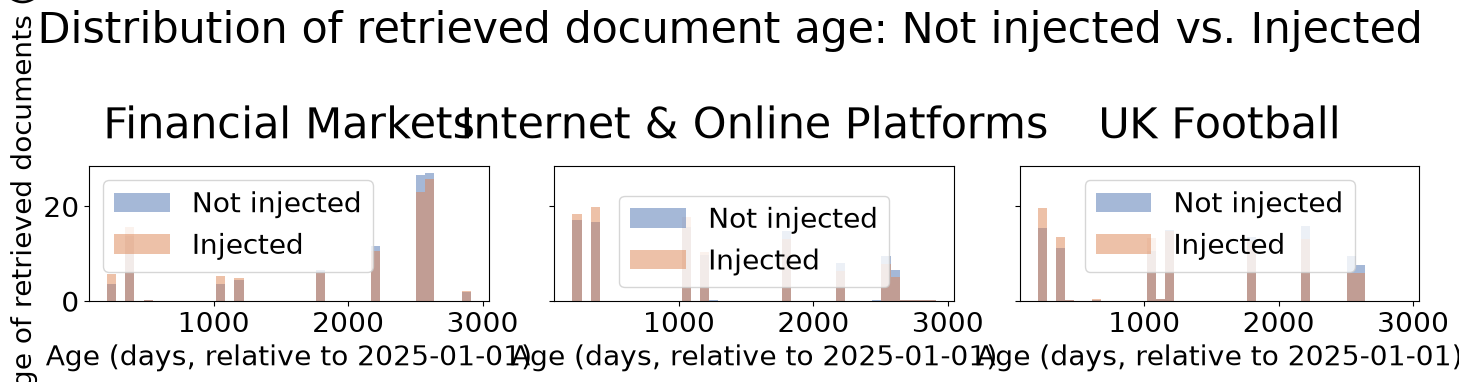

In [18]:
topics = sorted(df["topic"].unique())
n_topics = len(topics)


TOPIC_LABELS = {
    "fm": "Financial Markets",
    "ip": "Internet & Online Platforms",
    "uf": "UK Football",
}

fig, axes = plt.subplots(1, n_topics, figsize=(5 * n_topics, 4), sharey=True)
if n_topics == 1:
    axes = [axes]

n_bins = 40
bin_edges = np.linspace(df["age_days"].min(), df["age_days"].max(), n_bins + 1)

colors = {BASELINE_LABEL: BASELINE_COLOR, COMPARISON_LABEL: COMPARISON_COLOR}

for ax, topic in zip(axes, topics):
    subset = df[df["topic"] == topic]
    for group in [BASELINE_LABEL, COMPARISON_LABEL]:
        values = subset.loc[subset["group"] == group, "age_days"]
        if len(values) == 0:
            continue
        weights = np.full(len(values), 100 / len(values))
        ax.hist(
            values,
            bins=bin_edges,
            weights=weights,
            alpha=0.5,
            label=group,
            color=colors[group],
        )
    ax.set_title(TOPIC_LABELS.get(topic, topic))
    ax.set_xlabel(f"Age (days, relative to {REFERENCE_DATE.date()})")
    ax.legend()

axes[0].set_ylabel("Percentage of retrieved documents (%)")
fig.suptitle(f"Distribution of retrieved document age: {BASELINE_LABEL} vs. {COMPARISON_LABEL}")
plt.tight_layout()
plt.show()

## Butterfly chart: publication date distribution, baseline vs. comparison (all topics combined)
Retrieved documents are binned by publication date. Comparison counts are plotted above the x-axis, baseline counts below it, combining all topics.

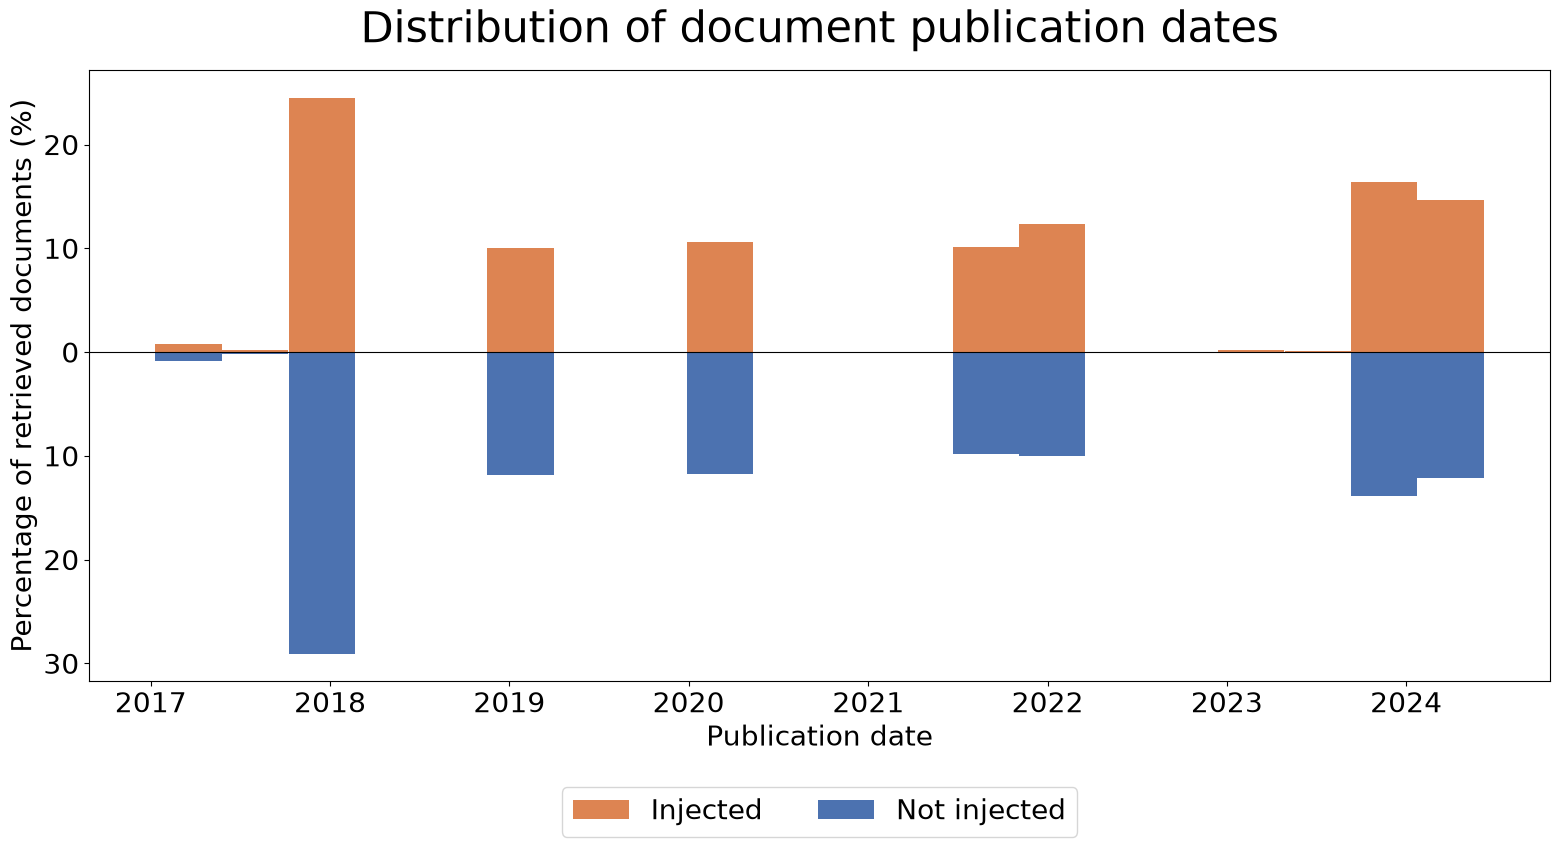

In [19]:
n_bins = 20

dates_numeric = df["published_date"].values.astype("datetime64[D]").astype(int)
bin_edges = np.linspace(dates_numeric.min(), dates_numeric.max(), n_bins + 1)
bin_centers = ((bin_edges[:-1] + bin_edges[1:]) / 2).astype("datetime64[D]")
bin_width = bin_edges[1] - bin_edges[0]

baseline_mask = df["group"] == BASELINE_LABEL
comparison_mask = df["group"] == COMPARISON_LABEL

baseline_counts, _ = np.histogram(dates_numeric[baseline_mask], bins=bin_edges)
comparison_counts, _ = np.histogram(dates_numeric[comparison_mask], bins=bin_edges)

baseline_pct = baseline_counts / baseline_counts.sum() * 100
comparison_pct = comparison_counts / comparison_counts.sum() * 100

fig, ax = plt.subplots(figsize=(16, 9))
ax.bar(bin_centers, comparison_pct, width=bin_width, color=COMPARISON_COLOR, label=COMPARISON_LABEL)
ax.bar(bin_centers, -baseline_pct, width=bin_width, color=BASELINE_COLOR, label=BASELINE_LABEL)
ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.set_major_formatter(lambda value, pos: f"{abs(value):g}")

ax.set_xlabel("Publication date")
ax.set_ylabel("Percentage of retrieved documents (%)")
ax.set_title("Distribution of document publication dates")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

## Overlayed bar chart: publication date distribution, baseline vs. comparison (all topics combined)

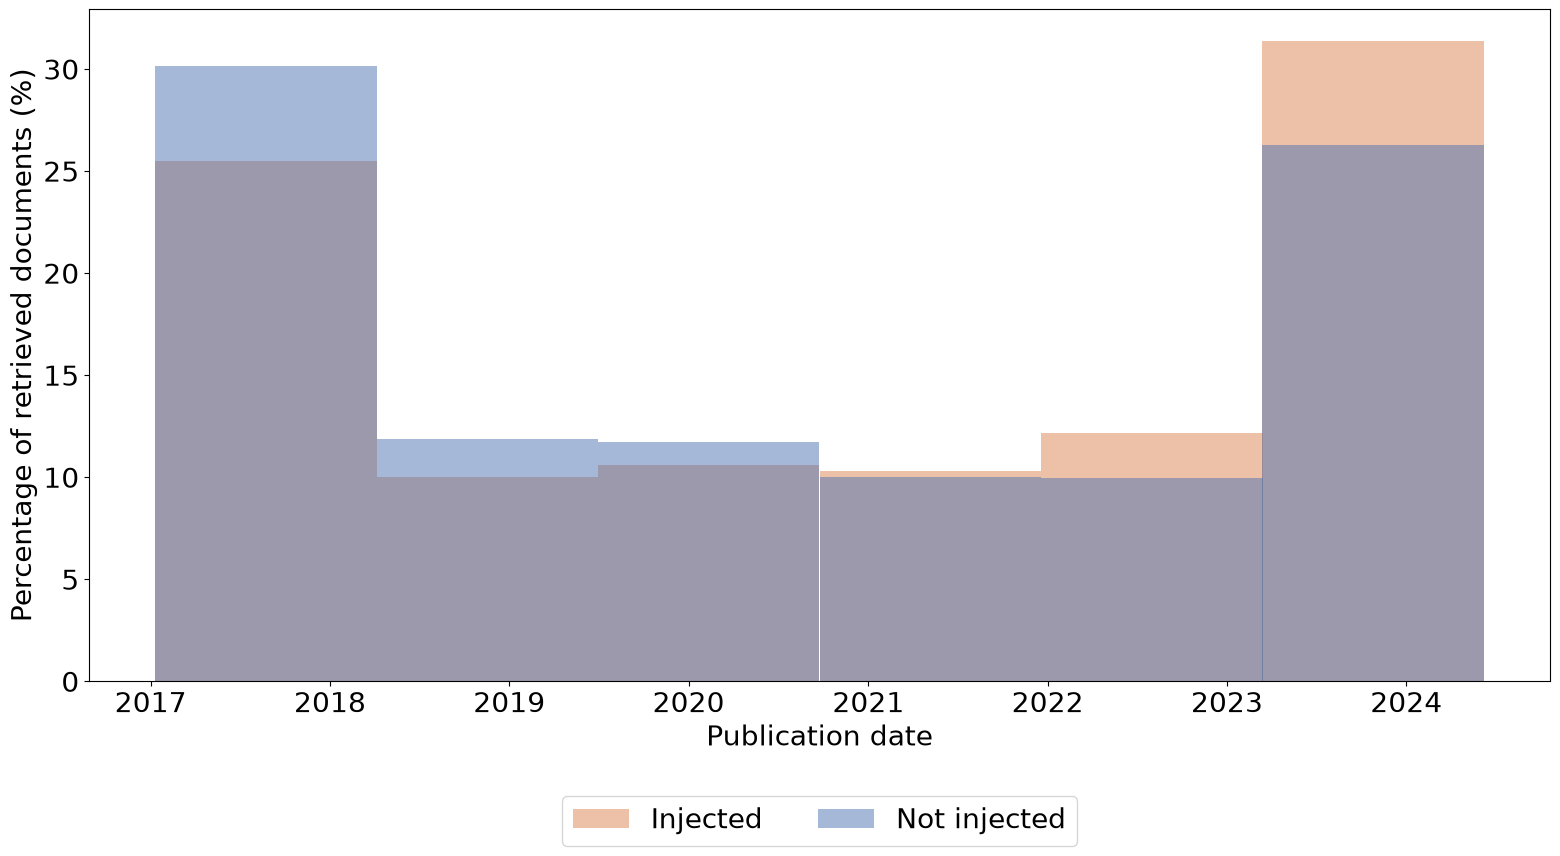

In [22]:
n_bins = 6

dates_numeric = df["published_date"].values.astype("datetime64[D]").astype(int)
bin_edges = np.linspace(dates_numeric.min(), dates_numeric.max(), n_bins + 1)
bin_centers = ((bin_edges[:-1] + bin_edges[1:]) / 2).astype("datetime64[D]")
bin_width = bin_edges[1] - bin_edges[0]

baseline_mask = df["group"] == BASELINE_LABEL
comparison_mask = df["group"] == COMPARISON_LABEL

baseline_counts, _ = np.histogram(dates_numeric[baseline_mask], bins=bin_edges)
comparison_counts, _ = np.histogram(dates_numeric[comparison_mask], bins=bin_edges)

baseline_pct = baseline_counts / baseline_counts.sum() * 100
comparison_pct = comparison_counts / comparison_counts.sum() * 100

fig, ax = plt.subplots(figsize=(16, 9))
ax.bar(bin_centers, comparison_pct, width=bin_width, color=COMPARISON_COLOR, alpha=0.5, label=COMPARISON_LABEL)
ax.bar(bin_centers, baseline_pct, width=bin_width, color=BASELINE_COLOR, alpha=0.5, label=BASELINE_LABEL)

ax.set_xlabel("Publication date")
ax.set_ylabel("Percentage of retrieved documents (%)")
#ax.set_title("Distribution of document publication dates")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

## Line chart: publication date distribution, baseline vs. comparison (all topics combined)

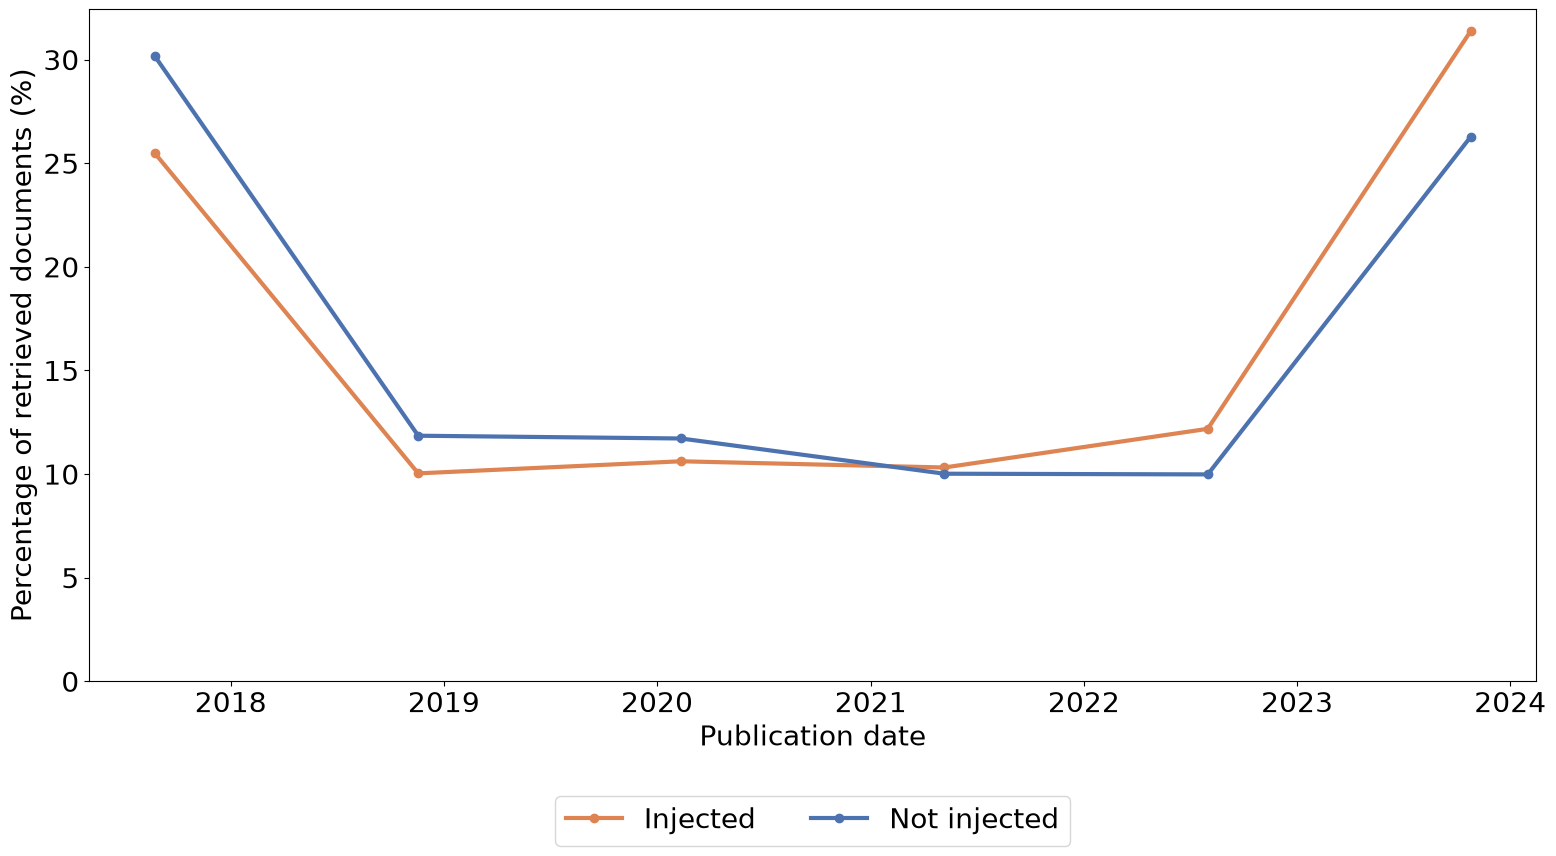

In [27]:
n_bins = 6

dates_numeric = df["published_date"].values.astype("datetime64[D]").astype(int)
bin_edges = np.linspace(dates_numeric.min(), dates_numeric.max(), n_bins + 1)
bin_centers = ((bin_edges[:-1] + bin_edges[1:]) / 2).astype("datetime64[D]")
bin_width = bin_edges[1] - bin_edges[0]

baseline_mask = df["group"] == BASELINE_LABEL
comparison_mask = df["group"] == COMPARISON_LABEL

baseline_counts, _ = np.histogram(dates_numeric[baseline_mask], bins=bin_edges)
comparison_counts, _ = np.histogram(dates_numeric[comparison_mask], bins=bin_edges)

baseline_pct = baseline_counts / baseline_counts.sum() * 100
comparison_pct = comparison_counts / comparison_counts.sum() * 100

fig, ax = plt.subplots(figsize=(16, 9))
ax.plot(bin_centers, comparison_pct, color=COMPARISON_COLOR, alpha=1, label=COMPARISON_LABEL, marker="o", linewidth=3)
ax.plot(bin_centers, baseline_pct, color=BASELINE_COLOR, alpha=1, label=BASELINE_LABEL, marker="o", linewidth=3)

ax.set_ylim(bottom=0)
ax.set_xlabel("Publication date")
ax.set_ylabel("Percentage of retrieved documents (%)")
#ax.set_title("Distribution of document publication dates")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()